In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import scipy.ndimage as ndi

from src.data.paths import project_dir
from src.data.analysis import read_tiff_img, Circle, create_circular_mask
from src.data.detector import DetectorDataCollection, DetectorData, DetectorImage

In [2]:
colors = [(0, 1, 0), (1, 0, 0)]  # green -> red
cmap_name = 'custom_cmap'
custom_cmap = LinearSegmentedColormap.from_list(cmap_name, colors)

In [3]:
# local paths
base_path = project_dir / 'data' / 'raw'
#base_path = Path.home() / 'OneDrive - ifj.edu.pl' / 'Projects' / 'MB_foils'

base_path.exists()

True

In [4]:
proton_path = base_path / '2025-10-09'
proton_path.exists()

True

In [5]:
import pickle
with open(proton_path / 'proton_denoised_data.pkl', 'rb') as f:
    data = pickle.load(f)

In [6]:
left_image = np.fliplr(data.data[1].raw.image)
right_image = np.fliplr(data.data[2].raw.image)

In [7]:
left_circle = Circle(x=left_image.shape[0]-data.data[1].circle.x, y=data.data[1].circle.y, r=data.data[1].circle.r)
right_circle = Circle(x=left_image.shape[0]-data.data[2].circle.x, y=data.data[2].circle.y, r=data.data[2].circle.r)
left_circle, right_circle 

(Circle(x=194.5, y=192.5, r=133.60000610351562),
 Circle(x=196.5, y=192.5, r=129.89999389648438))

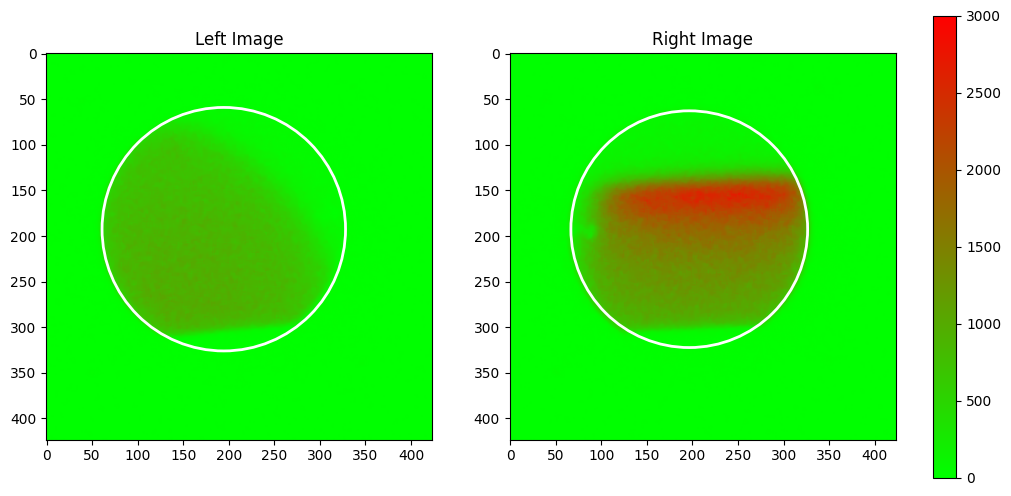

In [8]:
# plot left and right image side by side with vmax 3000 and custom cmap, add colorbar with colorscale
fig, ax = plt.subplots(1, 2, figsize=(12, 6))
im1 = ax[0].imshow(left_image, cmap=custom_cmap, vmax=3000)
circle1 = plt.Circle((left_circle.x, left_circle.y), left_circle.r, color='white', fill=False, linewidth=2)
ax[0].add_artist(circle1)
ax[0].set_title('Left Image')

im2 = ax[1].imshow(right_image, cmap=custom_cmap, vmax=3000)
ax[1].set_title('Right Image')
circle2 = plt.Circle((right_circle.x, right_circle.y), right_circle.r, color='white', fill=False, linewidth=2)
ax[1].add_artist(circle2)

plt.colorbar(im2, ax=ax, fraction=0.046, pad=0.04)

In [9]:
# Data classes and computation functions for vertical sections
from dataclasses import dataclass
from typing import List, Optional

@dataclass
class SectionResult:
    x: int
    profile: np.ndarray
    crossing_y: Optional[float]  # fractional y if found, else None

@dataclass
class ImageSections:
    image_name: str
    sections: List[SectionResult]


def compute_vertical_sections(img: np.ndarray, xs: List[int], stripe_width: int = 5, threshold: float = 400.0, search_from_bottom: bool = True) -> ImageSections:
    """Compute vertical profiles and interpolated crossings for given x positions.

    Returns an ImageSections object with per-section profiles and crossing points (fractional y).
    """
    import numpy as np
    h, w = img.shape
    half = stripe_width // 2

    def find_crossing_interpolated_bottom_to_top(profile, thr, y0, y1):
        sub = profile[y0:y1]
        idxs = np.where(sub >= thr)[0]
        if idxs.size == 0:
            return None
        last_idx = int(idxs.max())
        if last_idx == 0:
            return float(y0)
        prev = last_idx - 1
        v_low = float(sub[prev])
        v_high = float(sub[last_idx])
        if v_high == v_low:
            return float(y0 + last_idx)
        frac = (thr - v_low) / (v_high - v_low)
        return float(y0 + prev + frac)

    def find_crossing_interpolated_top_to_bottom(profile, thr, y0, y1):
        sub = profile[y0:y1]
        idxs = np.where(sub >= thr)[0]
        if idxs.size == 0:
            return None
        first_idx = int(idxs[0])
        if first_idx == 0:
            return float(y0)
        prev = first_idx - 1
        v_low = float(sub[prev])
        v_high = float(sub[first_idx])
        if v_high == v_low:
            return float(y0 + first_idx)
        frac = (thr - v_low) / (v_high - v_low)
        return float(y0 + prev + frac)

    finder = find_crossing_interpolated_bottom_to_top if search_from_bottom else find_crossing_interpolated_top_to_bottom

    sections: List[SectionResult] = []
    for x in xs:
        x0 = max(0, int(x - half))
        x1 = min(w, int(x + half + 1))
        section = img[:, x0:x1].astype(float)
        profile = np.nanmean(section, axis=1)
        y0_win, y1_win = 0, h
        crossing = finder(profile, threshold, y0_win, y1_win)
        sections.append(SectionResult(x=int(x), profile=profile, crossing_y=crossing))

    return ImageSections(image_name='image', sections=sections)


# Quick compute results for both images to make results available
left_sections = compute_vertical_sections(left_image, xs=[140,160,180,200,220,240,260], stripe_width=10, threshold=400, search_from_bottom=True)
right_sections = compute_vertical_sections(right_image, xs=[140,160,180,200,220,240,260], stripe_width=10, threshold=400, search_from_bottom=True)

print('Computed sections for left and right images')


Computed sections for left and right images


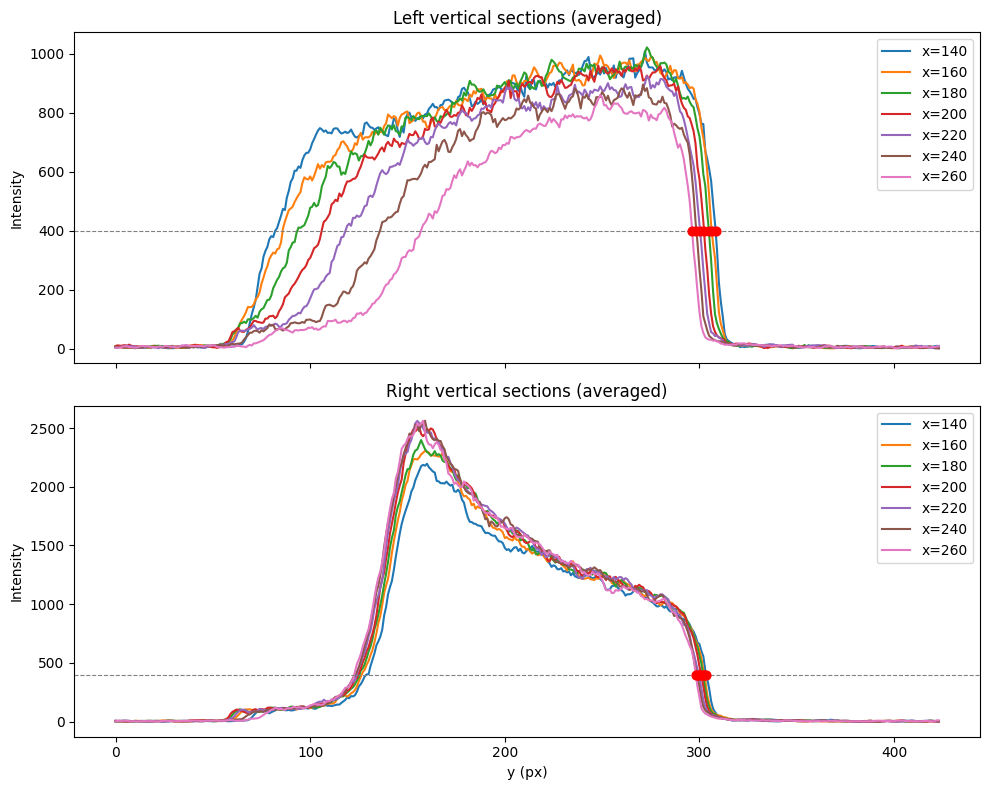

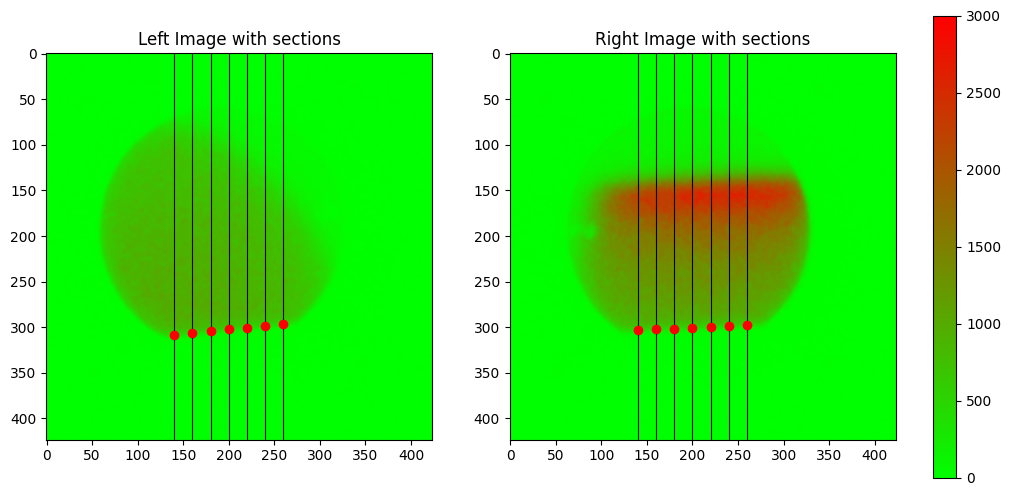

In [10]:
# Plotting functions that take ImageSections and draw plots

def plot_sections_profiles(left_sections: ImageSections, right_sections: ImageSections, threshold: float = 400.0):
    import matplotlib.pyplot as plt
    import numpy as np

    # assume both have same xs
    xs = [s.x for s in left_sections.sections]
    h = left_sections.sections[0].profile.size

    fig, axs = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
    for i, x in enumerate(xs):
        prof_l = left_sections.sections[i].profile
        prof_r = right_sections.sections[i].profile
        axs[0].plot(np.arange(h), prof_l, label=f'x={x}')
        axs[1].plot(np.arange(h), prof_r, label=f'x={x}')
        cl = left_sections.sections[i].crossing_y
        cr = right_sections.sections[i].crossing_y
        if cl is not None:
            axs[0].scatter(cl, threshold, s=40, color='red', zorder=5)
        if cr is not None:
            axs[1].scatter(cr, threshold, s=40, color='red', zorder=5)

    axs[0].axhline(threshold, color='gray', linestyle='--', linewidth=0.8)
    axs[1].axhline(threshold, color='gray', linestyle='--', linewidth=0.8)
    axs[0].set_title('Left vertical sections (averaged)')
    axs[0].set_ylabel('Intensity')
    axs[0].legend()
    axs[1].set_title('Right vertical sections (averaged)')
    axs[1].set_ylabel('Intensity')
    axs[1].set_xlabel('y (px)')
    axs[1].legend()
    plt.tight_layout()
    plt.show()


def overlay_sections_on_images(left_img, right_img, left_sections: ImageSections, right_sections: ImageSections):
    import matplotlib.pyplot as plt

    h, w = left_img.shape
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    im0 = ax[0].imshow(left_img, cmap=custom_cmap, vmax=3000)
    ax[0].set_title('Left Image with sections')
    im1 = ax[1].imshow(right_img, cmap=custom_cmap, vmax=3000)
    ax[1].set_title('Right Image with sections')

    xs = [s.x for s in left_sections.sections]
    for s in left_sections.sections:
        ax[0].plot([s.x, s.x], [0, h-1], color='black', linewidth=0.8)
        if s.crossing_y is not None:
            ax[0].plot(s.x, s.crossing_y, 'ro', markersize=6)
    for s in right_sections.sections:
        ax[1].plot([s.x, s.x], [0, h-1], color='black', linewidth=0.8)
        if s.crossing_y is not None:
            ax[1].plot(s.x, s.crossing_y, 'ro', markersize=6)

    plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

# Example usage with computed left_sections and right_sections
plot_sections_profiles(left_sections, right_sections, threshold=400)
overlay_sections_on_images(left_image, right_image, left_sections, right_sections)


In [11]:
# Dataclass for line result and function to compute a near-horizontal line from SectionResults
from dataclasses import dataclass
from typing import List, Optional, Tuple

@dataclass
class LineResult:
    slope: float
    intercept: float
    slope_deg: float
    used_points: List[Tuple[float, float]]  # list of (x, y)


def compute_edge_line(image_sections: ImageSections, min_points: int = 2, robust: bool = True) -> Optional[LineResult]:
    """Fit a line y = m*x + b through the crossing points from image_sections.

    Uses simple least squares; if robust option is True and scikit-learn is available, uses RANSAC.
    Returns None if not enough points.
    """
    import numpy as np
    xs = []
    ys = []
    for s in image_sections.sections:
        if s.crossing_y is not None:
            xs.append(float(s.x))
            ys.append(float(s.crossing_y))
    if len(xs) < min_points:
        return None
    xs_arr = np.array(xs)
    ys_arr = np.array(ys)

    # try robust fit with sklearn if available
    if robust:
        try:
            from sklearn.linear_model import RANSACRegressor, LinearRegression
            model = RANSACRegressor(LinearRegression(), min_samples=max(2, int(0.5 * len(xs_arr))))
            model.fit(xs_arr.reshape(-1, 1), ys_arr)
            m = float(model.estimator_.coef_[0])
            b = float(model.estimator_.intercept_)
            # compute inlier mask
            inlier_mask = model.inlier_mask_
            xs_used = xs_arr[inlier_mask].tolist()
            ys_used = ys_arr[inlier_mask].tolist()
        except Exception:
            # fallback to simple polyfit
            p = np.polyfit(xs_arr, ys_arr, 1)
            m, b = float(p[0]), float(p[1])
            xs_used = xs_arr.tolist()
            ys_used = ys_arr.tolist()
    else:
        p = np.polyfit(xs_arr, ys_arr, 1)
        m, b = float(p[0]), float(p[1])
        xs_used = xs_arr.tolist()
        ys_used = ys_arr.tolist()

    slope_deg = float(np.degrees(np.arctan(m)))
    used_pts = list(zip(xs_used, ys_used))
    return LineResult(slope=m, intercept=b, slope_deg=slope_deg, used_points=used_pts)


Left fitted slope (deg): -5.741240823728363
Right fitted slope (deg): -2.645863707680997


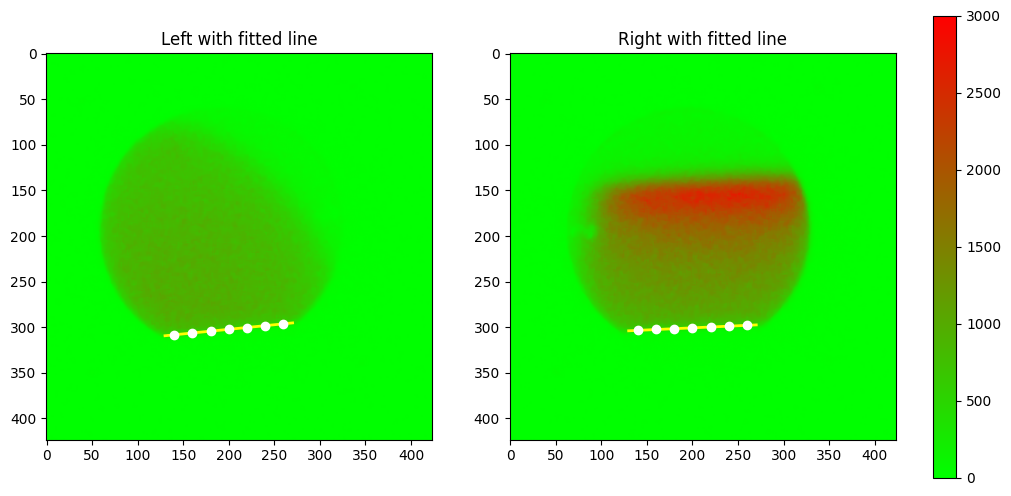

In [12]:
# Compute and overlay fitted lines on images
left_line = compute_edge_line(left_sections, robust=True)
right_line = compute_edge_line(right_sections, robust=True)

print('Left fitted slope (deg):', left_line.slope_deg if left_line else None)
print('Right fitted slope (deg):', right_line.slope_deg if right_line else None)

# function to overlay LineResult on existing overlay plot

def overlay_line_on_images(left_img, right_img, left_line: LineResult, right_line: LineResult, x_range=None, color='lime'):
    import numpy as np
    import matplotlib.pyplot as plt
    h, w = left_img.shape
    if x_range is None:
        x_range = (0, w-1)
    xs_plot = np.array([x_range[0], x_range[1]])

    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    im0 = ax[0].imshow(left_img, cmap=custom_cmap, vmax=3000)
    ax[0].set_title('Left with fitted line')
    im1 = ax[1].imshow(right_img, cmap=custom_cmap, vmax=3000)
    ax[1].set_title('Right with fitted line')

    if left_line is not None:
        y0 = left_line.slope * xs_plot[0] + left_line.intercept
        y1 = left_line.slope * xs_plot[1] + left_line.intercept
        ax[0].plot(xs_plot, [y0, y1], color=color, linewidth=2)
        # mark used points
        for (x, y) in left_line.used_points:
            ax[0].plot(x, y, 'wo')
    if right_line is not None:
        y0 = right_line.slope * xs_plot[0] + right_line.intercept
        y1 = right_line.slope * xs_plot[1] + right_line.intercept
        ax[1].plot(xs_plot, [y0, y1], color=color, linewidth=2)
        for (x, y) in right_line.used_points:
            ax[1].plot(x, y, 'wo')

    plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
    plt.show()

# Show overlay with lines
overlay_line_on_images(left_image, right_image, left_line, right_line, x_range=(130, 270), color='yellow')


In [13]:
# Function to rotate images by the calculated slope angle
def rotate_image_by_slope(img: np.ndarray, line_result: LineResult, angle_adjustment: float = 0.0, order: int = 3, cval: float = 0.0) -> np.ndarray:
    """Rotate image to make the fitted edge horizontal.
    
    Args:
        img: Input image array
        line_result: LineResult object containing slope information
        angle_adjustment: Additional angle (in degrees) to add to the rotation angle
        order: Interpolation order (0=nearest, 1=linear, 3=cubic)
        cval: Value to use for pixels outside image boundaries
    
    Returns:
        Rotated image array
    """
    if line_result is None:
        return img
    
    # Rotate by negative of the slope angle to make edge horizontal, plus any adjustment
    angle_deg = line_result.slope_deg + angle_adjustment
    
    # Use scipy.ndimage.rotate for rotation
    rotated = ndi.rotate(img, angle_deg, reshape=False, order=order, cval=cval)
    
    return rotated


In [14]:
# Function to rotate line parameters to match rotated image
def rotate_line_result(img_shape: tuple, line_result: LineResult, angle_deg: float) -> LineResult:
    """Rotate a LineResult to match a rotated image.
    
    Args:
        img_shape: Shape of the original image (h, w)
        line_result: Original LineResult object
        angle_deg: Rotation angle in degrees (same as used for image rotation)
    
    Returns:
        New LineResult with rotated line parameters
    """
    if line_result is None:
        return None
    
    h, w = img_shape
    center_x, center_y = w / 2.0, h / 2.0
    
    # Convert angle to radians
    angle_rad = np.radians(angle_deg)
    cos_a = np.cos(angle_rad)
    sin_a = np.sin(angle_rad)
    
    # Take several points along the original line
    x_points = np.linspace(0, w-1, 50)
    y_points = line_result.slope * x_points + line_result.intercept
    
    # Rotate these points around the center
    # Translation to origin
    x_centered = x_points - center_x
    y_centered = y_points - center_y
    
    # Rotation matrix application (note: positive angle rotates counter-clockwise)
    x_rot = cos_a * x_centered - sin_a * y_centered
    y_rot = sin_a * x_centered + cos_a * y_centered
    
    # Translation back
    x_rot += center_x
    y_rot += center_y
    
    # Fit a new line through the rotated points
    p = np.polyfit(x_rot, y_rot, 1)
    new_slope = float(p[0])
    new_intercept = float(p[1])
    new_slope_deg = float(np.degrees(np.arctan(new_slope)))
    
    # Rotate the used points as well
    rotated_used_points = []
    for (x, y) in line_result.used_points:
        x_c = x - center_x
        y_c = y - center_y
        x_r = cos_a * x_c - sin_a * y_c + center_x
        y_r = sin_a * x_c + cos_a * y_c + center_y
        rotated_used_points.append((x_r, y_r))
    
    return LineResult(slope=new_slope, intercept=new_intercept, 
                     slope_deg=new_slope_deg, used_points=rotated_used_points)


In [15]:
# Rotate both images using the calculated slope angles
left_image_rotated = rotate_image_by_slope(left_image, left_line, angle_adjustment=90.0, order=3, cval=0.0)
right_image_rotated = rotate_image_by_slope(right_image, right_line, angle_adjustment=-90.0, order=3, cval=0.0)

# Rotate the line parameters to match the rotated images
left_line_rotated = rotate_line_result(left_image.shape, left_line, -left_line.slope_deg-90)
right_line_rotated = rotate_line_result(right_image.shape, right_line, -right_line.slope_deg+90)

print(f'Left image rotated by {left_line.slope_deg:.3f} degrees')
print(f'Right image rotated by {right_line.slope_deg:.3f} degrees')
print(f'Rotated image shapes: {left_image_rotated.shape}, {right_image_rotated.shape}')
print(f'Left line slope after rotation: {left_line_rotated.slope_deg:.6f} degrees')
print(f'Right line slope after rotation: {right_line_rotated.slope_deg:.6f} degrees')


Left image rotated by -5.741 degrees
Right image rotated by -2.646 degrees
Rotated image shapes: (424, 424), (424, 424)
Left line slope after rotation: 20.210858 degrees
Right line slope after rotation: 39.937323 degrees


/tmp/ipykernel_67676/1145648785.py:42: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x_rot, y_rot, 1)
/tmp/ipykernel_67676/1145648785.py:42: RankWarning: Polyfit may be poorly conditioned
  p = np.polyfit(x_rot, y_rot, 1)


In [16]:
# Function to rotate circle center coordinates
def rotate_circle(img_shape: tuple, circle: Circle, angle_deg: float) -> Circle:
    """Rotate a circle's center point to match a rotated image.
    
    Args:
        img_shape: Shape of the original image (h, w)
        circle: Original Circle object
        angle_deg: Rotation angle in degrees (same as used for image rotation)
    
    Returns:
        New Circle with rotated center coordinates and same radius
    """
    if circle is None:
        return None
    
    h, w = img_shape
    center_x, center_y = w / 2.0, h / 2.0
    
    # Convert angle to radians
    angle_rad = np.radians(angle_deg)
    cos_a = np.cos(angle_rad)
    sin_a = np.sin(angle_rad)
    
    # Get circle center relative to image center
    x_centered = circle.x - center_x
    y_centered = circle.y - center_y
    
    # Apply rotation matrix
    x_rot = cos_a * x_centered - sin_a * y_centered
    y_rot = sin_a * x_centered + cos_a * y_centered
    
    # Translate back
    x_new = x_rot + center_x
    y_new = y_rot + center_y
    
    return Circle(x=x_new, y=y_new, r=circle.r)


In [17]:
# Function to plot rotated images with fitted lines
def plot_rotated_images(left_img_rot, right_img_rot, left_line_rot=None, right_line_rot=None, 
                       left_circle_plot=None, right_circle_plot=None, vmax=3000):
    """Plot rotated images with fitted lines and optional rotated circles overlaid.
    
    Args:
        left_img_rot: Rotated left image
        right_img_rot: Rotated right image
        left_line_rot: Rotated LineResult for left image (optional)
        right_line_rot: Rotated LineResult for right image (optional)
        left_circle_plot: Circle object to overlay on left rotated image (optional)
        right_circle_plot: Circle object to overlay on right rotated image (optional)
        vmax: Maximum value for color scale
    """
      
    fig, ax = plt.subplots(1, 2, figsize=(12, 6))
    
    im0 = ax[0].imshow(left_img_rot, cmap=custom_cmap, vmax=vmax)
    ax[0].set_title('Left Image (Rotated)')
    
    im1 = ax[1].imshow(right_img_rot, cmap=custom_cmap, vmax=vmax)
    ax[1].set_title('Right Image (Rotated)')
    
    # Overlay fitted lines if provided
    if left_line_rot is not None:
        for (x, y) in left_line_rot.used_points:
            ax[0].plot(x, y, 'wo', markersize=4)
    
    if right_line_rot is not None:
        for (x, y) in right_line_rot.used_points:
            ax[1].plot(x, y, 'wo', markersize=4)

    # Overlay rotated circles if provided
    if left_circle_plot is not None:
        circ_left = plt.Circle((left_circle_plot.x, left_circle_plot.y), left_circle_plot.r,
                               edgecolor='r', facecolor='none', linewidth=2)
        ax[0].add_patch(circ_left)

    if right_circle_plot is not None:
        circ_right = plt.Circle((right_circle_plot.x, right_circle_plot.y), right_circle_plot.r,
                                edgecolor='b', facecolor='none', linewidth=2)
        ax[1].add_patch(circ_right)
    
    plt.colorbar(im1, ax=ax, fraction=0.046, pad=0.04)
    plt.show()


Left circle (rotated): center=(190.85,227.46), r=133.60
Right circle (rotated): center=(232.19,197.42), r=129.90


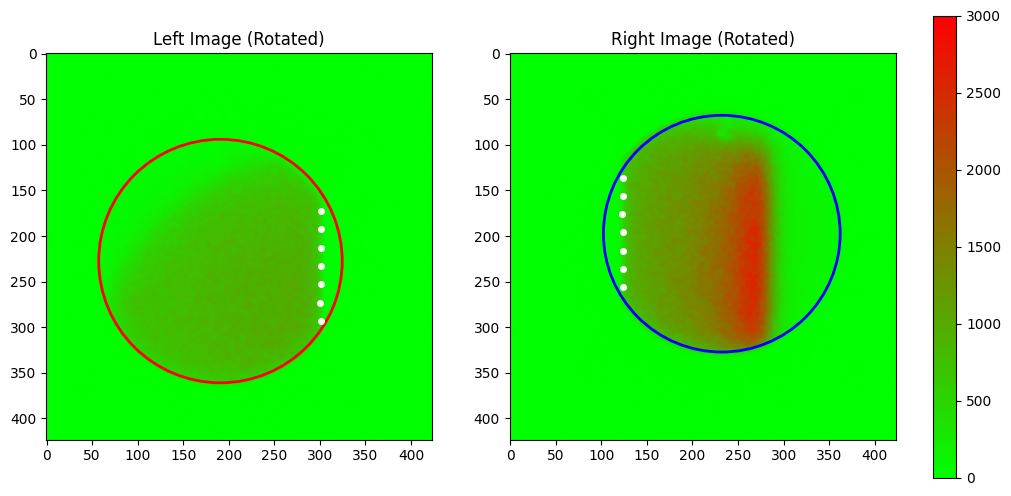

In [18]:
# Plot rotated images with fitted lines and rotated circles
# Compute rotated circle positions using the same rotation convention used for lines/images
left_circle_rotated = rotate_circle(left_image.shape, left_circle, -left_line.slope_deg-90)
right_circle_rotated = rotate_circle(right_image.shape, right_circle, -right_line.slope_deg+90)

print(f'Left circle (rotated): center=({left_circle_rotated.x:.2f},{left_circle_rotated.y:.2f}), r={left_circle_rotated.r:.2f}')
print(f'Right circle (rotated): center=({right_circle_rotated.x:.2f},{right_circle_rotated.y:.2f}), r={right_circle_rotated.r:.2f}')

# Plot rotated images with fitted lines and the rotated circles
plot_rotated_images(left_image_rotated, right_image_rotated,
                   left_line_rot=left_line_rotated, right_line_rot=right_line_rotated,
                   left_circle_plot=left_circle_rotated, right_circle_plot=right_circle_rotated,
                   vmax=3000)


In [19]:
## Crop images to 300x300 with center at (150, 150)

In [20]:
def crop_image_centered(image, center_x, center_y, crop_size=300):
    """Crop image so that (center_x, center_y) becomes (150, 150) in the cropped image.
    
    Args:
        image: Input image array
        center_x: X-coordinate of the point that should be at (150, 150)
        center_y: Y-coordinate of the point that should be at (150, 150)
        crop_size: Size of the cropped image (default 300x300)
        
    Returns:
        Cropped image of size (crop_size, crop_size)
    """
    import numpy as np
    
    # Calculate the offset - we want center_x, center_y to be at 150, 150
    half_size = crop_size // 2
    
    # Calculate the top-left corner of the crop in the original image
    x_start = int(center_x - half_size)
    y_start = int(center_y - half_size)
    
    # Crop the image
    cropped = image[y_start:y_start + crop_size, x_start:x_start + crop_size]
    
    return cropped, (x_start, y_start)


# Crop left and right images
left_image_cropped, left_offset = crop_image_centered(
    left_image_rotated, 
    left_circle_rotated.x, 
    left_circle_rotated.y, 
    crop_size=300
)

right_image_cropped, right_offset = crop_image_centered(
    right_image_rotated,
    right_circle_rotated.x,
    right_circle_rotated.y,
    crop_size=300
)

print(f'Left image cropped from offset: ({left_offset[0]}, {left_offset[1]})')
print(f'Right image cropped from offset: ({right_offset[0]}, {right_offset[1]})')
print(f'Left image cropped shape: {left_image_cropped.shape}')
print(f'Right image cropped shape: {right_image_cropped.shape}')

Left image cropped from offset: (40, 77)
Right image cropped from offset: (82, 47)
Left image cropped shape: (300, 300)
Right image cropped shape: (300, 300)


In [21]:
def transform_circle(circle, offset_x, offset_y):
    """Transform circle coordinates by subtracting the offset.
    
    Args:
        circle: Circle object with x, y, r attributes
        offset_x: X offset to subtract
        offset_y: Y offset to subtract
        
    Returns:
        New Circle object with transformed coordinates
    """
    from src.data.analysis import Circle
    return Circle(
        x=circle.x - offset_x,
        y=circle.y - offset_y,
        r=circle.r
    )


def transform_line(line_result, offset_x, offset_y):
    """Transform line points by subtracting the offset.
    
    Args:
        line_result: LineResult object with used_points
        offset_x: X offset to subtract
        offset_y: Y offset to subtract
        
    Returns:
        New LineResult object with transformed points
    """
    transformed_points = [(x - offset_x, y - offset_y) for x, y in line_result.used_points]
    return LineResult(
        slope=line_result.slope,
        intercept=line_result.intercept - line_result.slope * offset_x + offset_y,
        slope_deg=line_result.slope_deg,
        used_points=transformed_points
    )


# Transform circles
left_circle_cropped = transform_circle(left_circle_rotated, left_offset[0], left_offset[1])
right_circle_cropped = transform_circle(right_circle_rotated, right_offset[0], right_offset[1])

print(f'Left circle (cropped): center=({left_circle_cropped.x:.2f},{left_circle_cropped.y:.2f}), r={left_circle_cropped.r:.2f}')
print(f'Right circle (cropped): center=({right_circle_cropped.x:.2f},{right_circle_cropped.y:.2f}), r={right_circle_cropped.r:.2f}')

# Transform lines
left_line_cropped = transform_line(left_line_rotated, left_offset[0], left_offset[1])
right_line_cropped = transform_line(right_line_rotated, right_offset[0], right_offset[1])

print(f'Left line (cropped): {len(left_line_cropped.used_points)} points transformed')
print(f'Right line (cropped): {len(right_line_cropped.used_points)} points transformed')

Left circle (cropped): center=(150.85,150.46), r=133.60
Right circle (cropped): center=(150.19,150.42), r=129.90
Left line (cropped): 7 points transformed
Right line (cropped): 7 points transformed


In [22]:
left_line_cropped

LineResult(slope=0.3681435305443057, intercept=172.9859770080642, slope_deg=20.210857671418804, used_points=[(np.float64(260.6619969338483), np.float64(216.2770876292551)), (np.float64(260.5358833918684), np.float64(196.16357882102062)), (np.float64(261.0371969329286), np.float64(176.1131517080311)), (np.float64(260.7554229383182), np.float64(155.98399275414633)), (np.float64(260.7808134152735), np.float64(135.88571620255044)), (np.float64(260.69702886453695), np.float64(115.77646316299064)), (np.float64(260.6400277912876), np.float64(95.66990294178396))])

In [23]:
right_line_cropped

LineResult(slope=0.8372371919487064, intercept=82.0600938978468, slope_deg=39.93732260109481, used_points=[(np.float64(42.09801164244959), np.float64(88.86104486859065)), (np.float64(42.084753340777624), np.float64(108.88177617323223)), (np.float64(41.07511366633719), np.float64(128.85646281453964)), (np.float64(41.89025631754272), np.float64(148.91547609034552)), (np.float64(42.12334974645546), np.float64(168.94759177330505)), (np.float64(42.16496733865581), np.float64(188.97085899654925)), (np.float64(41.69512361715802), np.float64(208.9704906273975))])

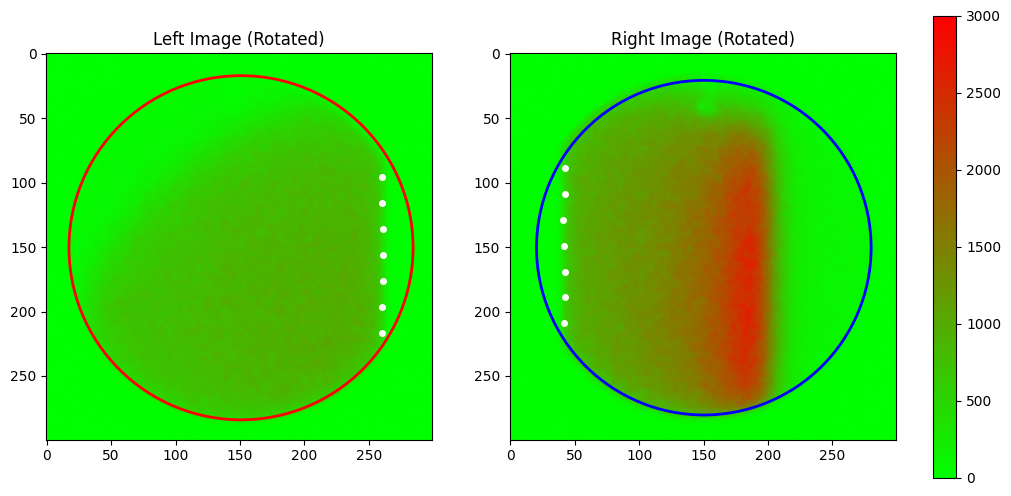

In [24]:
# Plot cropped images with transformed circles and lines
plot_rotated_images(left_image_cropped, right_image_cropped,
                   left_line_rot=left_line_cropped, right_line_rot=right_line_cropped,
                   left_circle_plot=left_circle_cropped, right_circle_plot=right_circle_cropped,
                   vmax=3000)

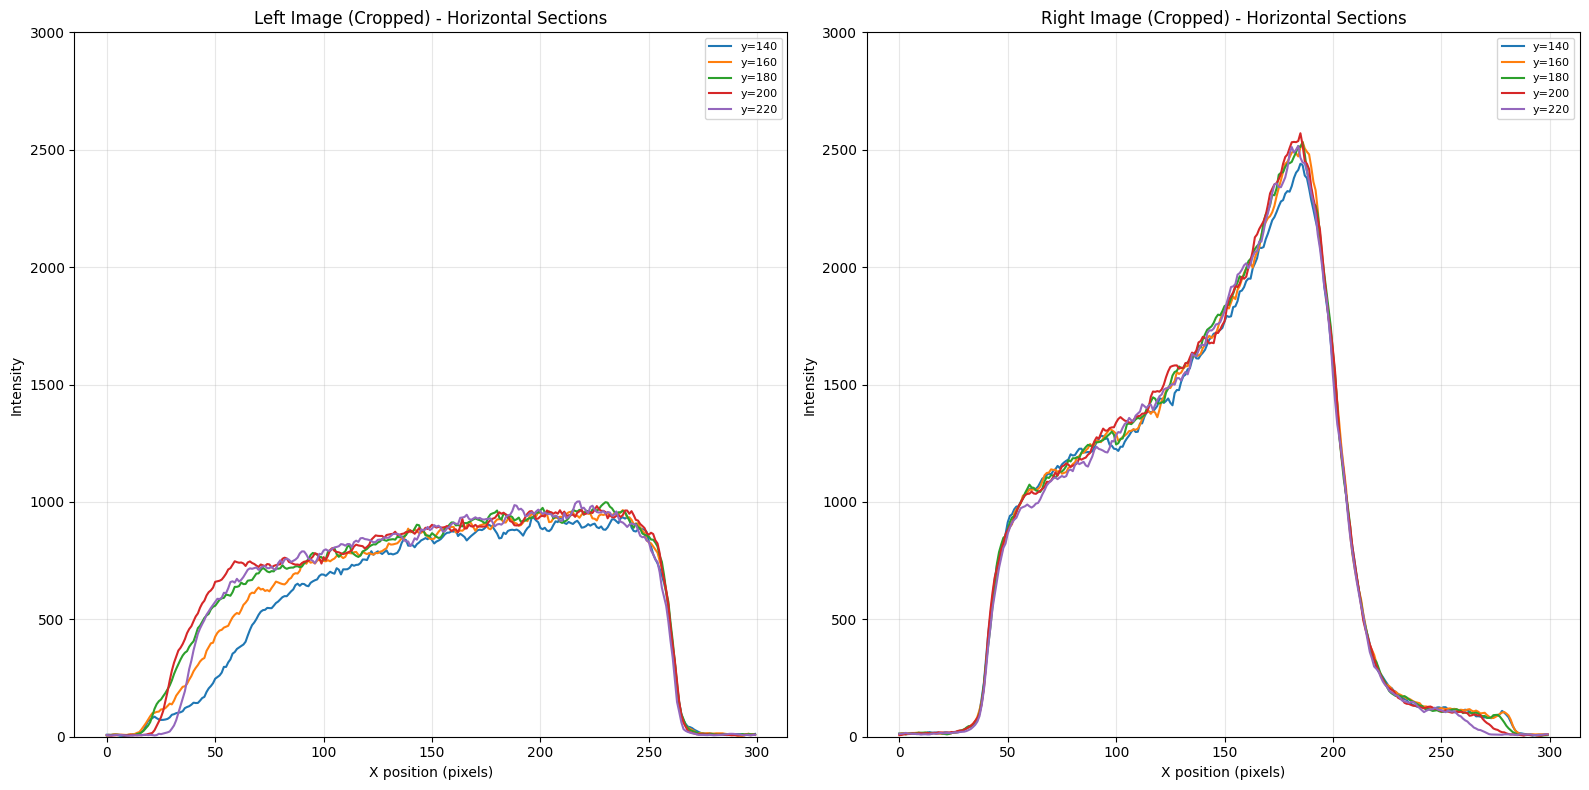

In [25]:
# Plot horizontal sections at multiple y positions
import numpy as np

# Define positions and width
y_positions = range(140, 221, 20)
width = 20  # 10 pixels width

fig, (ax_left, ax_right) = plt.subplots(1, 2, figsize=(16, 8))

# Plot sections for left (cropped) image
for y_pos in y_positions:
    # Extract horizontal section (average over width)
    y_start = max(0, y_pos - width // 2)
    y_end = min(left_image_cropped.shape[0], y_pos + width // 2)
    section = left_image_cropped[y_start:y_end, :].mean(axis=0)
    ax_left.plot(section, label=f'y={y_pos}')

ax_left.set_xlabel('X position (pixels)')
ax_left.set_ylabel('Intensity')
ax_left.set_title('Left Image (Cropped) - Horizontal Sections')
ax_left.set_ylim(0, 3000)
ax_left.legend(loc='best', fontsize=8)
ax_left.grid(True, alpha=0.3)

# Plot sections for right (cropped) image
for y_pos in y_positions:
    # Extract horizontal section (average over width)
    y_start = max(0, y_pos - width // 2)
    y_end = min(right_image_cropped.shape[0], y_pos + width // 2)
    section = right_image_cropped[y_start:y_end, :].mean(axis=0)
    ax_right.plot(section, label=f'y={y_pos}')

ax_right.set_xlabel('X position (pixels)')
ax_right.set_ylabel('Intensity')
ax_right.set_title('Right Image (Cropped) - Horizontal Sections')
ax_right.set_ylim(0, 3000)
ax_right.legend(loc='best', fontsize=8)
ax_right.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
def merge_images_with_crop(left_img, right_img, left_edge, right_edge, margin,
                           right_circle, right_line):
    """
    Merge left and right images by cropping and concatenating.
    
    Args:
        left_img: Left image array
        right_img: Right image array
        left_edge: X coordinate of left edge
        right_edge: X coordinate of right edge
        margin: Margin for cropping
        right_circle: Circle object from right image to transform
        right_line: LineResult from right image to transform
        
    Returns:
        merged_image: The merged image array
        transformed_circle: The transformed circle for the merged image
        transformed_line: The transformed line for the merged image
    """
    import numpy as np
    from dataclasses import replace
    
    # Calculate crop positions
    left_crop_x = int(left_edge + margin)
    right_crop_x = int(right_edge - margin)
    
    # Crop the images
    left_cropped = left_img[:, :left_crop_x]
    right_cropped = right_img[:, right_crop_x:]
    
    # Merge horizontally
    merged = np.concatenate([left_cropped, right_cropped], axis=1)
    
    # Transform right circle (shift X coordinate by the offset)
    x_offset = left_crop_x - right_crop_x
    transformed_circle = Circle(
        x=right_circle.x + x_offset,
        y=right_circle.y,
        r=right_circle.r
    )
    
    # Transform right line used_points (shift X coordinates)
    transformed_points = [(x + x_offset, y) for x, y in right_line.used_points]
    transformed_line = LineResult(
        slope=right_line.slope,
        intercept=right_line.intercept + right_line.slope * x_offset,
        slope_deg=right_line.slope_deg,
        used_points=transformed_points
    )
    
    print(f'Left image cropped at x={left_crop_x}, shape: {left_cropped.shape}')
    print(f'Right image cropped at x={right_crop_x}, shape: {right_cropped.shape}')
    print(f'Merged image shape: {merged.shape}')
    print(f'Right circle transformed: x={right_circle.x:.2f} -> {transformed_circle.x:.2f}')
    print(f'X offset applied: {x_offset}')
    
    return merged, transformed_circle, transformed_line

In [27]:
# Calculate edge positions from line points
left_edge = np.mean([x for x, y in left_line_cropped.used_points])
right_edge = np.mean([x for x, y in right_line_cropped.used_points])
margin = 1

print(f'Left edge: {left_edge:.2f}')
print(f'Right edge: {right_edge:.2f}')
print(f'Margin: {margin}')

Left edge: 260.73
Right edge: 41.88
Margin: 1


In [28]:
# Apply the merge function
merged_image, merged_circle, merged_line = merge_images_with_crop(
    left_image_cropped, right_image_cropped,
    left_edge, right_edge, margin,
    right_circle_cropped, right_line_cropped
)

Left image cropped at x=261, shape: (300, 261)
Right image cropped at x=40, shape: (300, 260)
Merged image shape: (300, 521)
Right circle transformed: x=150.19 -> 371.19
X offset applied: 221


/tmp/ipykernel_67676/3739504635.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend()


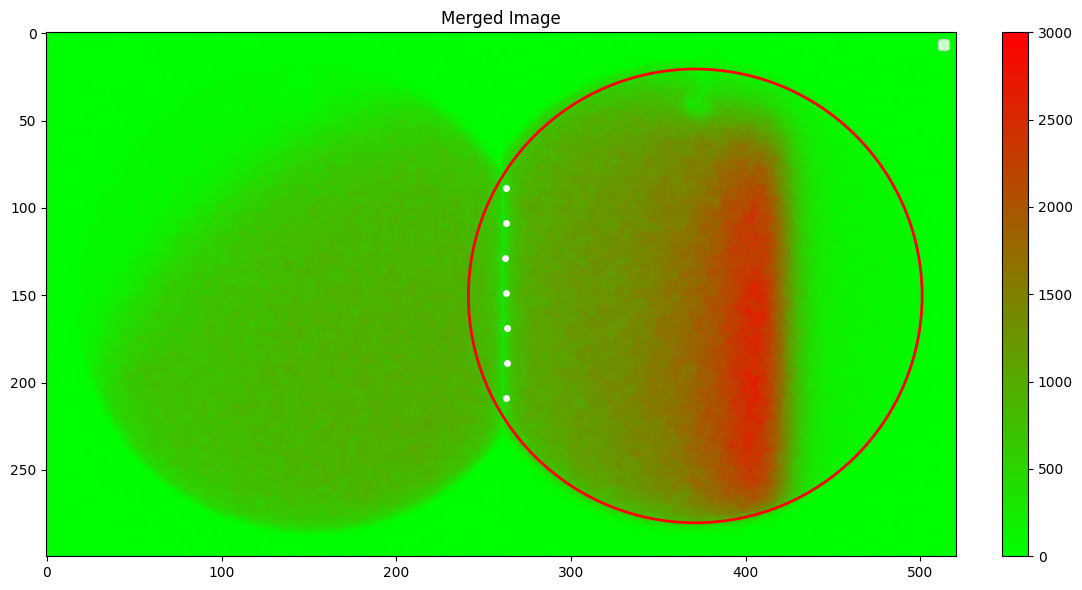

In [29]:
# Plot the merged image with transformed circle and line
fig, ax = plt.subplots(1, 1, figsize=(12, 6))

im = ax.imshow(merged_image, cmap=custom_cmap, vmax=3000)
ax.set_title('Merged Image')

# Draw the transformed circle
circle_patch = plt.Circle((merged_circle.x, merged_circle.y), merged_circle.r, 
                          color='red', fill=False, linewidth=2)
ax.add_patch(circle_patch)

# Draw the transformed line points
for (x, y) in merged_line.used_points:
    ax.plot(x, y, 'wo', markersize=4)


ax.legend()
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
plt.show()

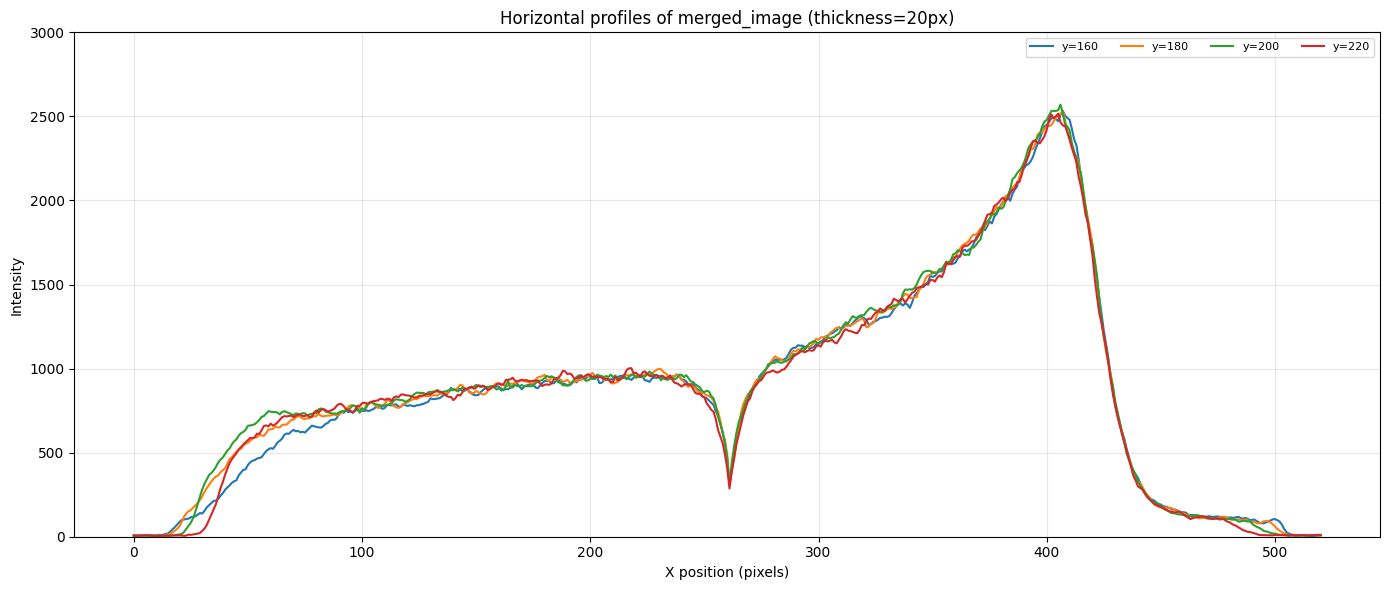

In [30]:
# Plot horizontal profiles of the merged image at given thickness
import numpy as np
import matplotlib.pyplot as plt

thickness = 20  # px
y_positions = range(160, 221, 20)  # 60, 80, 100, ..., 220

fig, ax = plt.subplots(1, 1, figsize=(14, 6))

h, w = merged_image.shape
for y in y_positions:
    y0 = max(0, int(y - thickness // 2))
    y1 = min(h, int(y + thickness // 2))
    # average a horizontal stripe [y0:y1) across rows to get 1D profile along X
    stripe = merged_image[y0:y1, :].astype(float)
    profile = np.nanmean(stripe, axis=0)
    ax.plot(profile, label=f'y={y}')

ax.set_xlabel('X position (pixels)')
ax.set_ylabel('Intensity')
ax.set_title(f'Horizontal profiles of merged_image (thickness={thickness}px)')
ax.set_ylim(0, 3000)
ax.grid(True, alpha=0.3)
ax.legend(ncols=4, fontsize=8)
plt.tight_layout()
plt.show()

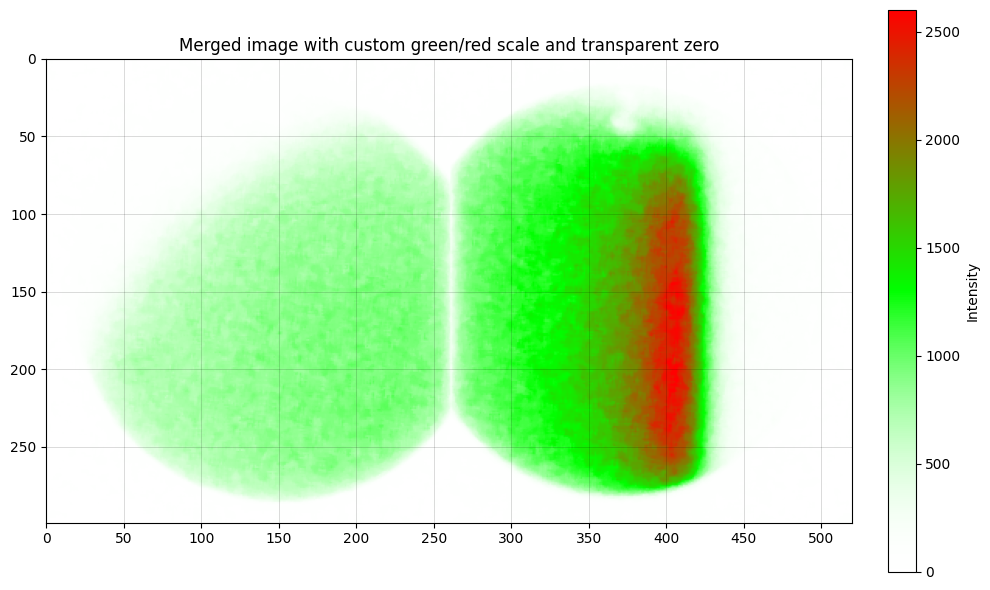

In [31]:
# Plot merged_image with custom colormap (0->white transparent, 1300->green, 2600->red) and grid every 50px
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

# Build colormap: 0 -> white with alpha 0, 1300 -> green, 2600 -> red
vmin, vmax = 0, 2600
cmap_merge = LinearSegmentedColormap.from_list(
    'merge_cmap',
    [
        (0.0, (1.0, 1.0, 1.0, 0.0)),      # 0 -> transparent white
        (1300.0 / vmax, (0.0, 1.0, 0.0, 1.0)),  # 1300 -> green
        (1.0, (1.0, 0.0, 0.0, 1.0)),      # 2600 -> red
    ]
)

fig, ax = plt.subplots(1, 1, figsize=(10, 6))
ax.set_facecolor('white')  # ensure transparency shows as white

im = ax.imshow(merged_image, cmap=cmap_merge, vmin=vmin, vmax=vmax)
ax.set_title('Merged image with custom green/red scale and transparent zero')

# Thin grid lines every 50 px
h, w = merged_image.shape
ax.set_xticks(np.arange(0, w + 1, 50))
ax.set_yticks(np.arange(0, h + 1, 50))
ax.grid(True, which='both', color='k', alpha=0.2, linewidth=0.5)
ax.set_xlim(0, w-1)
ax.set_ylim(h-1, 0)

# Optional colorbar (vmax fixed to 2600)
cbar = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cbar.set_label('Intensity')

plt.tight_layout()
plt.show()

In [36]:
# 3D interactive surface of merged_image (Plotly if available, else Matplotlib)
import numpy as np

h, w = merged_image.shape
Y, X = np.meshgrid(np.arange(h), np.arange(w), indexing='ij')

try:
    import plotly.graph_objects as go
    # Colorscale matching earlier style: 0->white, 1300->green, 2600->red
    colorscale = [
        [0.0, 'rgba(255,255,255,0.0)'],
        [1300/2600, 'rgb(0,255,0)'],
        [1.0, 'rgb(255,0,0)'],
    ]
    fig = go.Figure(data=[go.Surface(x=X, y=Y, z=merged_image, colorscale=colorscale, cmin=0, cmax=2600, showscale=True)])
    fig.update_layout(
        title='merged_image 3D surface',
        width=1200, height=1000,
        scene=dict(
            xaxis_title='X (px)', yaxis_title='Y (px)', zaxis_title='Intensity',
            xaxis=dict(dtick=50), yaxis=dict(dtick=50), zaxis=dict(range=[0,2700])
        )
    )
    fig.show()
except Exception as e:
    print('Plotly not available or failed, falling back to Matplotlib 3D. Reason:', e)
    import matplotlib.pyplot as plt
    from matplotlib.colors import LinearSegmentedColormap
    from mpl_toolkits.mplot3d import Axes3D  # noqa: F401

    # Build a similar colormap for Matplotlib
    cmap_3d = LinearSegmentedColormap.from_list(
        'merge_cmap_3d',
        [
            (0.0, (1.0, 1.0, 1.0, 0.0)),
            (1300/2600, (0.0, 1.0, 0.0, 1.0)),
            (1.0, (1.0, 0.0, 0.0, 1.0)),
        ]
    )

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection='3d')
    surf = ax.plot_surface(X, Y, merged_image, cmap=cmap_3d, vmin=0, vmax=2600, linewidth=0, antialiased=True, rstride=2, cstride=2)
    ax.set_title('merged_image 3D surface (Matplotlib)')
    ax.set_xlabel('X (px)')
    ax.set_ylabel('Y (px)')
    ax.set_zlabel('Intensity')
    ax.set_zlim(0, 2600)
    fig.colorbar(surf, shrink=0.6, aspect=12)
    plt.tight_layout()
    plt.show()

In [33]:
import plotly.graph_objects as go